In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
import time
import os
import copy

cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [ ]:
data_dir = './data'

image_datasets = {
    'train': datasets.CIFAR10(root=data_dir, train=True, download=True, transform=data_transforms['train']),
    'val': datasets.CIFAR10(root=data_dir, train=False, download=True, transform=data_transforms['val']),
}

100%|██████████| 170M/170M [17:37<00:00, 161kB/s]


In [ ]:
dataloaders = {
    x: torch.utils.data.DataLoader(image_datasets[x], batch_size=64, shuffle=(x == 'train'), num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Dataset sizes: {'train': 50000, 'val': 10000}


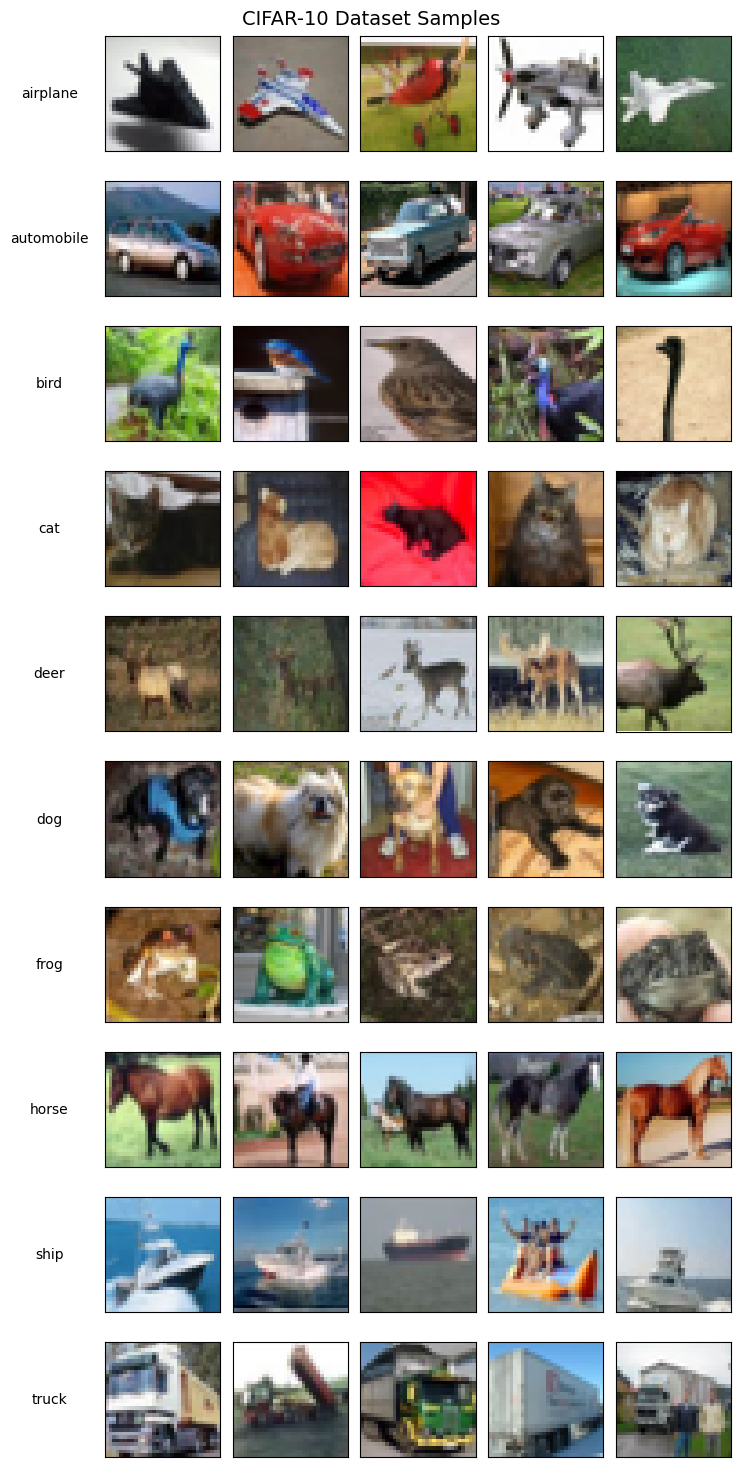

In [ ]:
import matplotlib.pyplot as plt

raw_dataset = datasets.CIFAR10(root=data_dir, train=True, download=True)

samples_per_class = 5
fig, axes = plt.subplots(len(class_names), samples_per_class,
                          figsize=(samples_per_class * 1.5, len(class_names) * 1.5))

for class_idx, class_name in enumerate(class_names):
    class_indices = [i for i, label in enumerate(raw_dataset.targets) if label == class_idx][:samples_per_class]

    for col, idx in enumerate(class_indices):
        img, _ = raw_dataset[idx]
        ax = axes[class_idx, col]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(class_name, rotation=0, labelpad=40, fontsize=10, va='center')

plt.suptitle('CIFAR-10 Dataset Samples', fontsize=14)
plt.tight_layout()
plt.show()

# Baseline Setup

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=5):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
model_conv = models.resnet152(weights='IMAGENET1K_V2')

for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, len(class_names))

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 148MB/s]


In [ ]:
NUM_EPOCHS = 5

model_conv, history = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

print("\nTraining history:")
for epoch in range(NUM_EPOCHS):
  print(f"Epoch {epoch}: "
        f"train_loss={history['train_loss'][epoch]:.4f}, "
        f"train_acc={history['train_acc'][epoch]:.4f}, "
        f"val_loss={history['val_loss'][epoch]:.4f}, "
        f"val_acc={history['val_acc'][epoch]:.4f}")

torch.save(model_conv.state_dict(), 'resnet152_cifar10_head.pt')

Epoch 0/4
----------
train Loss: 1.6257 Acc: 0.4909
val Loss: 1.0787 Acc: 0.7135

Epoch 1/4
----------
train Loss: 1.3044 Acc: 0.5669
val Loss: 0.9142 Acc: 0.7377

Epoch 2/4
----------
train Loss: 1.2311 Acc: 0.5822
val Loss: 0.8318 Acc: 0.7549

Epoch 3/4
----------
train Loss: 1.1880 Acc: 0.5920
val Loss: 0.7994 Acc: 0.7615

Epoch 4/4
----------
train Loss: 1.1629 Acc: 0.6015
val Loss: 0.7707 Acc: 0.7692

Training complete in 39m 55s
Best val Acc: 0.769200

Training history:
Epoch 0: train_loss=1.6257, train_acc=0.4909, val_loss=1.0787, val_acc=0.7135
Epoch 1: train_loss=1.3044, train_acc=0.5669, val_loss=0.9142, val_acc=0.7377
Epoch 2: train_loss=1.2311, train_acc=0.5822, val_loss=0.8318, val_acc=0.7549
Epoch 3: train_loss=1.1880, train_acc=0.5920, val_loss=0.7994, val_acc=0.7615
Epoch 4: train_loss=1.1629, train_acc=0.6015, val_loss=0.7707, val_acc=0.7692


In [ ]:
import json

with open('training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

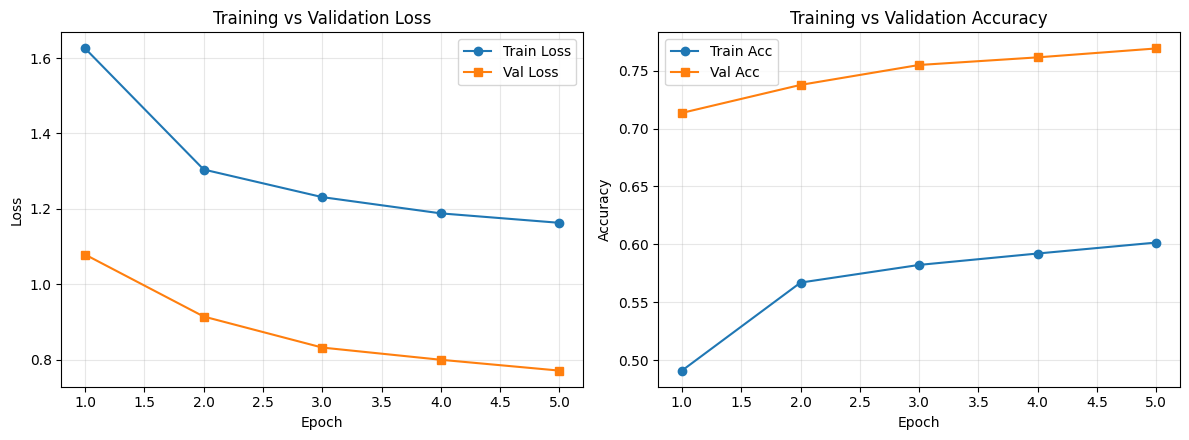

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Loss curve
    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 's-', label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training vs Validation Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy curve
    axes[1].plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], 's-', label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training vs Validation Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history)

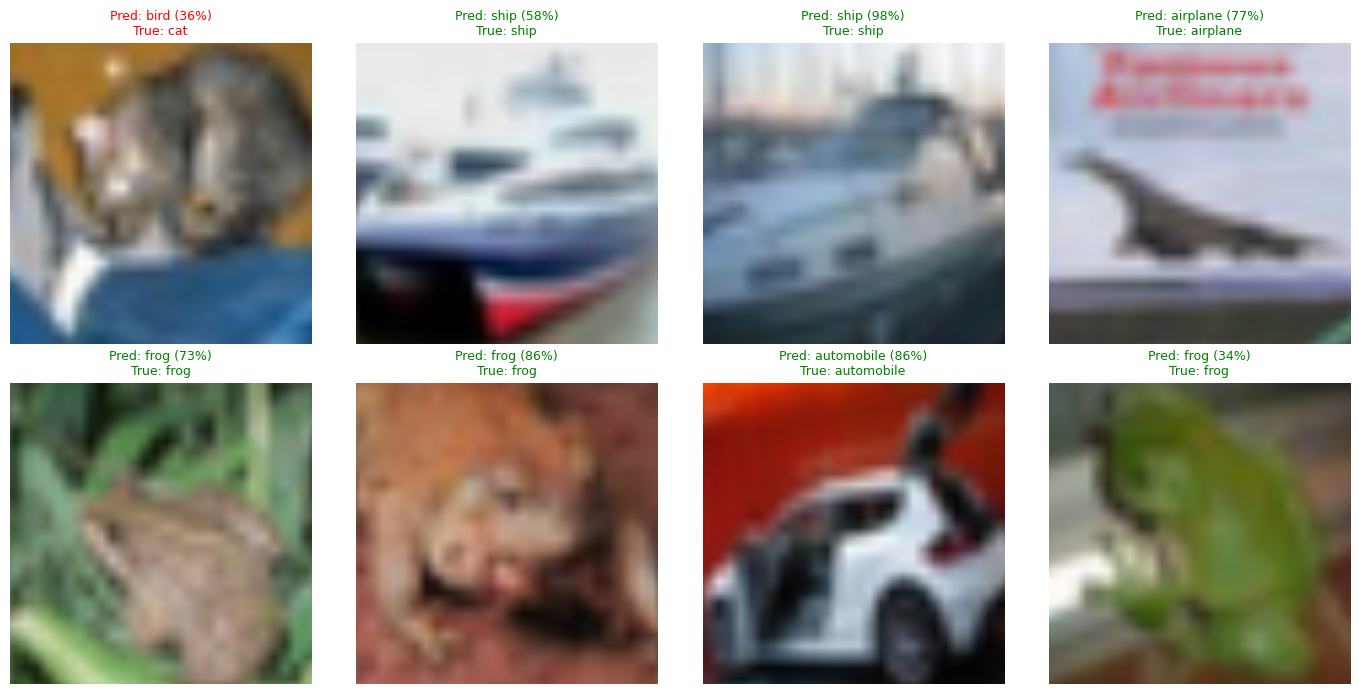

In [ ]:
import numpy as np

def imshow_tensor(inp, ax, mean, std):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)
    ax.axis('off')

def visualize_predictions(model, dataloader, class_names, device, num_images=8):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    was_training = model.training
    model.eval()

    images_so_far = 0
    fig = plt.figure(figsize=(14, 7))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            confs, preds = torch.max(probs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(2, num_images // 2, images_so_far)

                pred_label = class_names[preds[j]]
                true_label = class_names[labels[j]]
                conf = confs[j].item() * 100
                correct = preds[j] == labels[j]

                color = 'green' if correct else 'red'
                ax.set_title(f'Pred: {pred_label} ({conf:.0f}%)\nTrue: {true_label}',
                             color=color, fontsize=9)

                imshow_tensor(inputs.cpu().data[j], ax, mean, std)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    plt.savefig('inference_examples.png', dpi=150, bbox_inches='tight')
                    plt.show()
                    return

    model.train(mode=was_training)

visualize_predictions(model_conv, dataloaders['val'], class_names, device, num_images=8)

# Residuals Connections in Practice

In [ ]:
import types
import torch.nn as nn

In [ ]:
def make_no_skip_forward(block):
    """
    Same as torchvision's Bottleneck.forward, except it drops the
    `out += identity` residual addition (paper: y = F(x, {W_i}) + x
    -> disabling the skip removes only the "+ x" term).
    """
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # identity / downsample(x) intentionally NOT added here
        out = self.relu(out)

        return out
    return forward

In [ ]:
def disable_skip_connections(model, block_specs):
    modified = []
    for layer_name, block_idx in block_specs:
        layer = getattr(model, layer_name)
        block = layer[block_idx]
        block.forward = types.MethodType(make_no_skip_forward(block), block)
        modified.append(f'{layer_name}[{block_idx}]')
    print(f'Skip connections disabled in: {modified}')
    return model

In [ ]:
# Build modified model: same pretrained ResNet-152, same frozen backbone,
# same replaced FC head as baseline -- but 4 blocks lose their skip connection
model_noskip = models.resnet152(weights='IMAGENET1K_V2')

for param in model_noskip.parameters():
    param.requires_grad = False

num_ftrs = model_noskip.fc.in_features
model_noskip.fc = nn.Linear(num_ftrs, len(class_names))

# one block per layer group (layer1: 3 blocks, layer2: 8, layer3: 36, layer4: 3)
block_specs = [
    ('layer1', 1),
    ('layer2', 4),
    ('layer3', 18),
    ('layer4', 1),
]

model_noskip = disable_skip_connections(model_noskip, block_specs)
model_noskip = model_noskip.to(device)

criterion_noskip = nn.CrossEntropyLoss()
optimizer_noskip = optim.SGD(model_noskip.fc.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler_noskip = lr_scheduler.StepLR(optimizer_noskip, step_size=7, gamma=0.1)

Skip connections disabled in: ['layer1[1]', 'layer2[4]', 'layer3[18]', 'layer4[1]']


In [ ]:
NUM_EPOCHS = 5

model_noskip, history_noskip = train_model(
    model_noskip, criterion_noskip, optimizer_noskip, exp_lr_scheduler_noskip,
    num_epochs=NUM_EPOCHS
)

print("\nNo-Skip Training history:")
for epoch in range(NUM_EPOCHS):
  print(f"Epoch {epoch}: "
        f"train_loss={history_noskip['train_loss'][epoch]:.4f}, "
        f"train_acc={history_noskip['train_acc'][epoch]:.4f}, "
        f"val_loss={history_noskip['val_loss'][epoch]:.4f}, "
        f"val_acc={history_noskip['val_acc'][epoch]:.4f}")

torch.save(model_noskip.state_dict(), 'resnet152_cifar10_noskip_head.pt')

Epoch 0/4
----------
train Loss: 2.3028 Acc: 0.0993
val Loss: 2.3199 Acc: 0.1074

Epoch 1/4
----------
train Loss: 2.3025 Acc: 0.1004
val Loss: 2.3200 Acc: 0.1066

Epoch 2/4
----------
train Loss: 2.3023 Acc: 0.1016
val Loss: 2.3104 Acc: 0.1024

Epoch 3/4
----------
train Loss: 2.3022 Acc: 0.1023
val Loss: 2.3147 Acc: 0.1118

Epoch 4/4
----------
train Loss: 2.3020 Acc: 0.1002
val Loss: 2.3194 Acc: 0.1050

Training complete in 39m 24s
Best val Acc: 0.111800

No-Skip Training history:
Epoch 0: train_loss=2.3028, train_acc=0.0993, val_loss=2.3199, val_acc=0.1074
Epoch 1: train_loss=2.3025, train_acc=0.1004, val_loss=2.3200, val_acc=0.1066
Epoch 2: train_loss=2.3023, train_acc=0.1016, val_loss=2.3104, val_acc=0.1024
Epoch 3: train_loss=2.3022, train_acc=0.1023, val_loss=2.3147, val_acc=0.1118
Epoch 4: train_loss=2.3020, train_acc=0.1002, val_loss=2.3194, val_acc=0.1050


Comparison between baseline and No skip connections

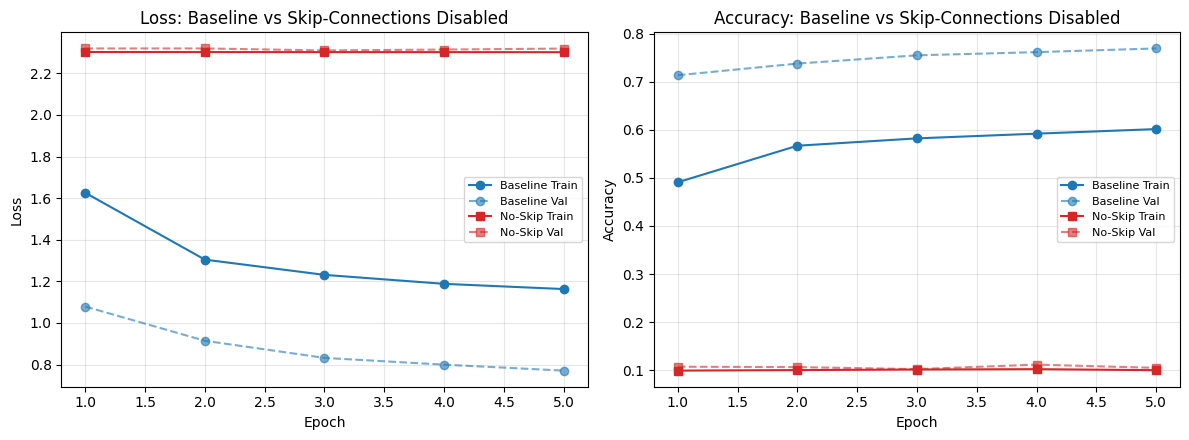

Metric              Baseline       No-Skip        
--------------------------------------------------
Final val acc       0.7692         0.1050         
Final val loss      0.7707         2.3194         
Best val acc        0.7692         0.1118         


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs, history['train_loss'], 'o-', color='tab:blue', label='Baseline Train')
axes[0].plot(epochs, history['val_loss'], 'o--', color='tab:blue', alpha=0.6, label='Baseline Val')
axes[0].plot(epochs, history_noskip['train_loss'], 's-', color='tab:red', label='No-Skip Train')
axes[0].plot(epochs, history_noskip['val_loss'], 's--', color='tab:red', alpha=0.6, label='No-Skip Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: Baseline vs Skip-Connections Disabled')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'o-', color='tab:blue', label='Baseline Train')
axes[1].plot(epochs, history['val_acc'], 'o--', color='tab:blue', alpha=0.6, label='Baseline Val')
axes[1].plot(epochs, history_noskip['train_acc'], 's-', color='tab:red', label='No-Skip Train')
axes[1].plot(epochs, history_noskip['val_acc'], 's--', color='tab:red', alpha=0.6, label='No-Skip Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy: Baseline vs Skip-Connections Disabled')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'Metric':<20}{'Baseline':<15}{'No-Skip':<15}")
print(f"{'Final val acc':<20}{history['val_acc'][-1]:<15.4f}{history_noskip['val_acc'][-1]:<15.4f}")
print(f"{'Final val loss':<20}{history['val_loss'][-1]:<15.4f}{history_noskip['val_loss'][-1]:<15.4f}")
print(f"{'Best val acc':<20}{max(history['val_acc']):<15.4f}{max(history_noskip['val_acc']):<15.4f}")

# Summary
print(f"{'Metric':<20}{'Baseline':<15}{'No-Skip':<15}")
print("-" * 50)

print(
    f"{'Final val acc':<20}"
    f"{history['val_acc'][-1]:<15.4f}"
    f"{history_noskip['val_acc'][-1]:<15.4f}"
)

print(
    f"{'Final val loss':<20}"
    f"{history['val_loss'][-1]:<15.4f}"
    f"{history_noskip['val_loss'][-1]:<15.4f}"
)

print(
    f"{'Best val acc':<20}"
    f"{max(history['val_acc']):<15.4f}"
    f"{max(history_noskip['val_acc']):<15.4f}"
)

In [ ]:
import json

with open('training_history_noskip.json', 'w') as f:
    json.dump(history_noskip, f, indent=2)